# Week 9: Prompting, LLM API และ Context Engineering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aofphy/SCI193611_ARTIFICIAL_INTELLIGENCE/blob/main/labs/w09_prompting_context.ipynb)

**Objective:** เรียก LLM ให้ได้ผลลัพธ์ที่ **วัดได้** ไม่ใช่แค่ "รู้สึกว่าดี"

1. client ตัวเดียวที่ใช้ได้กับทุกผู้ให้บริการ
2. ชุดประเมิน (eval set) และการวัดพรอมป์ต
3. ผลลัพธ์แบบมีโครงสร้างที่ validate ได้
4. การจัดการหน้าต่างบริบท

ส่วนที่ 2 ถึง 4 รันได้ทันทีด้วยโมเดลจำลอง จึงไม่ต้องมี API key ก็ทำแล็บได้ครบ

## 1) Client ที่ไม่ผูกกับผู้ให้บริการ

ผู้ให้บริการเกือบทุกรายเปิด endpoint ที่เข้ากันได้กับ OpenAI
จึงเปลี่ยนโมเดลได้โดยแก้แค่ `base_url` กับชื่อโมเดล

**ห้าม hard-code API key** ให้ใช้ตัวแปรสภาพแวดล้อมเสมอ

In [29]:
import os
import importlib
from dotenv import load_dotenv

# โหลดค่าจากไฟล์ .env (ใช้ override=True เพื่อบังคับทับความจำเก่า)
load_dotenv(override=True)

# --- จากนั้นตามด้วยโค้ดเดิมของอาจารย์ ---
try:                                    
    import llm as api
    importlib.reload(api) 
except ImportError:                   
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/aofphy/"
        "SCI193611_ARTIFICIAL_INTELLIGENCE/main/labs/llm.py", "llm.py")
    import llm as api

print(api.describe(api.resolve()))
print("มี key ในสภาพแวดล้อม:",
      [p for p, (_, k, _) in api.PROVIDERS.items() if os.environ.get(k)])

def make_llm(provider=None, model=None, **defaults):
    opts = {"temperature": 0, "max_tokens": 256, **defaults}
    def f(messages, **kw):
        return api.chat(messages, provider=provider, model=model, **{**opts, **kw})
    return f

try:
    print("โมเดลจริงตอบว่า:",
          make_llm()([{"role": "user", "content": "ตอบว่า OK clark"}]))
except Exception as e:
    print("ยังต่อโมเดลจริงไม่ได้:", type(e).__name__, e)

provider=openrouter  model=openrouter/free  base_url=https://openrouter.ai/api/v1  key=ตั้งแล้ว (73 อักขระ)
มี key ในสภาพแวดล้อม: ['openrouter']
โมเดลจริงตอบว่า: OK clark


### โมเดลจำลองสำหรับทำแล็บแบบออฟไลน์

`FakeLLM` เลียนแบบพฤติกรรมที่เจอจริง: ตอบถูกเป็นส่วนใหญ่ แต่บางครั้ง
เติมคำอธิบายเกินมาหรือใช้คำที่ไม่ตรงรูปแบบ ซึ่งเป็นสิ่งที่ชุดประเมินต้องจับให้ได้

In [30]:
import random, re

class FakeLLM:
    """โมเดลจำลอง: ใช้กฎง่าย ๆ + สุ่มความไม่สม่ำเสมอตามระดับที่กำหนด"""
    POS = ["อร่อย", "ดีเยี่ยม", "ประทับใจ", "คุ้ม", "ยอม", "ชอบ"]
    NEG = ["เย็นชืด", "รอ", "แย่", "ผิดหวัง", "ไม่คุ้ม", "หายาก"]

    def __init__(self, sloppiness=0.25, seed=0):
        self.sloppiness = sloppiness
        self.rng = random.Random(seed)

    def __call__(self, messages, **kw):
        text = messages[-1]["content"]
        few_shot = "คำตอบ:" in text            # พรอมป์ตที่มีตัวอย่างช่วยคุมรูปแบบ
        body = text.split("รีวิว:")[-1]
        p = sum(w in body for w in self.POS)
        n = sum(w in body for w in self.NEG)
        label = "บวก" if p > n else "ลบ" if n > p else "กลาง"
        if self.rng.random() < self.sloppiness * (0.2 if few_shot else 1.0):
            return f"จากการวิเคราะห์ รีวิวนี้มีความรู้สึกเชิง{label}ครับ"
        return label

fake = FakeLLM()
print(fake([{"role": "user", "content": "รีวิว: อาหารอร่อยมาก บริการดีเยี่ยม"}]))

บวก


## 1. ต่อ `make_llm` เข้ากับโมเดลจริงอย่างน้อย 2 ผู้ให้บริการ (แนะนำ Ollama บนเครื่อง + อีก 1 API)

In [5]:
import re
import json
import re

# ==========================================
# 1. ประกาศฟังก์ชัน make_llm
# ==========================================
def make_llm(provider="ollama", api_key="", model_name=None):
    if provider == "ollama":
        model = model_name or "llama3"
        def llm_fn(messages):
            url = "http://localhost:11434/api/chat"
            payload = {
                "model": model,
                "messages": messages,
                "stream": False,
                "options": {"temperature": 0.0}
            }
            try:
                res = requests.post(url, json=payload)
                res.raise_for_status()
                return res.json()["message"]["content"]
            except Exception as e:
                return f"Ollama Connection Error: {e}"
        return llm_fn

    elif provider == "openrouter":
        model = model_name or "google/gemma-2-9b-it:free"
        def llm_fn(messages):
            url = "https://openrouter.ai/api/v1/chat/completions"
            headers = {
                "Authorization": f"Bearer {api_key}",
                "Content-Type": "application/json"
            }
            payload = {
                "model": model,
                "messages": messages,
                "temperature": 0.0
            }
            res = requests.post(url, headers=headers, json=payload)
            res.raise_for_status()
            return res.json()["choices"][0]["message"]["content"]
        return llm_fn


## 2) ชุดประเมิน: หัวใจของงานนี้

20 เคสที่คัดมาให้ครอบคลุมกรณีขอบ มีค่ามากกว่า 1000 เคสที่สุ่มมา

In [6]:
CASES = [
    ("อาหารอร่อยมาก บริการดีเยี่ยม", "บวก"),
    ("รอ 40 นาที อาหารมาเย็นชืด", "ลบ"),
    ("ราคาปกติ รสชาติพอใช้ได้", "กลาง"),
    ("ที่จอดรถหายาก แต่ของอร่อยจนยอมเดิน", "บวก"),
    ("ร้านสะอาด ของอร่อย คุ้มมาก", "บวก"),
    ("ไม่คุ้มราคาเลย ผิดหวัง", "ลบ"),
    ("เฉย ๆ ไม่มีอะไรน่าจดจำ", "กลาง"),
    ("เปิดเพลงดังรบกวน พูดด้วยก็ไม่ได้ยิน", "ลบ"),
    ("เมนูหลากหลาย วัตถุดิบสดใหม่ทุกอย่าง", "บวก"),
    ("เค็มจัดจนทานไม่ได้ ต้องเหลือทิ้ง", "ลบ"),
    ("ร้านเปิด 10 โมงถึงทุ่มนึง หยุดวันจันทร์", "กลาง"),
    ("ไอศกรีมเข้มข้น หอมนม อร่อยมาก", "บวก"),
    ("เช็คบิลช้า พนักงานหน้าบึ้งใส่", "ลบ"),
    ("รสชาติมาตรฐานเหมือนสาขาอื่น", "กลาง"),
    ("วิวสวย บรรยากาศดี ถ่ายรูปเพลิน", "บวก"),
    
    # --- เคสกำกวม / ปะปน / ประชดประชัน (5 เคส) ---
    ("พนักงานยิ้มแย้ม แต่รอนานมาก", "กลาง"),             # ชมกับบ่นคานกันพอดี
    ("อาหารอร่อยมาก แต่กินเสร็จแล้วท้องเสีย", "ลบ"),       # ต้นบวก ปลายลบหนักมาก
    ("อร่อยจนอยากจะกราบ แต่เห็นราคาแล้วกราบไม่ลง", "กลาง"), # ชมรสชาติแต่บ่นราคา
    ("ปริมาณเยอะมาก กินยังไงก็ไม่หมด", "กลาง"),            # อาจเป็นข้อดีหรือข้อเสียขึ้นกับบริบท
    ("นึกว่าเป็นร้านอาหาร ที่ไหนได้หวานอย่างกับร้านขนม", "ลบ")  # ประชดประชัน (Sarcasm)
]

import re, json

# 1. พรอมป์ตทั้ง 3 รูปแบบ
ZERO_SHOT = "จำแนกความรู้สึกของรีวิวนี้ ตอบเฉพาะคำว่า บวก ลบ หรือ กลาง เท่านั้น\n\nรีวิว: {x}"

FEW_SHOT = """จำแนกความรู้สึกของรีวิว ตอบเฉพาะคำว่า บวก ลบ หรือ กลาง เท่านั้น

รีวิว: อาหารอร่อยมาก บริการดีเยี่ยม
คำตอบ: บวก

รีวิว: รอ 40 นาที อาหารมาเย็นชืด
คำตอบ: ลบ

รีวิว: ราคาปกติ รสชาติพอใช้ได้
คำตอบ: กลาง

รีวิว: {x}
คำตอบ:"""

JSON_PROMPT = """จำแนกความรู้สึกของรีวิวนี้ และตอบกลับเป็น JSON เท่านั้น ในรูปแบบ:
{{"label": "บวก|ลบ|กลาง", "confidence": 0.0-1.0, "reason": "เหตุผลย่อ"}}

รีวิว: {x}"""

VALID = {"บวก", "ลบ", "กลาง"}

# 2. ฟังก์ชันประเมินผลครอบคลุม Parse Failure และ Tokens
def evaluate_advanced(llm_fn, template, cases=CASES, is_json=False):
    wrong = []
    parse_failures = 0
    total_tokens = 0
    
    for text, want in cases:
        prompt_text = template.format(x=text)
        messages = [{"role": "user", "content": prompt_text}]
        
        # นับโทเคนขาเข้า (Prompt Tokens)
        total_tokens += sum(len(m["content"].encode()) for m in messages) // 3
        
        try:
            raw_res = llm_fn(messages)
            # นับโทเคนขาออก (Completion Tokens)
            total_tokens += len(raw_res.encode()) // 3
            
            got = ""
            if is_json:
                # พยายาม Parse JSON
                m = re.search(r"\{.*\}", raw_res, re.S)
                if not m:
                    raise ValueError("ไม่พบ JSON")
                d = json.loads(m.group())
                label = d.get("label")
                if label not in VALID:
                    raise ValueError("Label ไม่ถูกต้อง")
                got = label
            else:
                # พรอมป์ตปกติ: ข้อความต้องกระชับตรงคำ
                cleaned = raw_res.strip()
                if cleaned in VALID:
                    got = cleaned
                else:
                    parse_failures += 1  # นับเป็น Parse Failure เพราะตอบมีขยะติดมา
                    # พยายามสกัดเอาเฉพาะคำตอบเพื่อวัด Accuracy ต่อ
                    m = re.search(r"(บวก|ลบ|กลาง)", cleaned)
                    got = m.group(1) if m else cleaned
                    
            if got != want:
                wrong.append((text, want, got, raw_res))
                
        except Exception as e:
            parse_failures += 1
            wrong.append((text, want, f"PARSE_ERROR: {e}", raw_res))
            
    acc = 1 - (len(wrong) / len(cases))
    fail_rate = parse_failures / len(cases)
    return acc, fail_rate, total_tokens, wrong

# ----------------------------------------------------
# ทดสอบรันกับโมเดลจริง (ใช้ make_llm() ที่ต่อไว้)
# ----------------------------------------------------
llm = make_llm()

results = {}
prompts = [
    ("Zero-Shot", ZERO_SHOT, False),
    ("Few-Shot", FEW_SHOT, False),
    ("JSON Forced", JSON_PROMPT, True)
]

print(f"{'Prompt Type':<15} | {'Accuracy':<10} | {'Parse Fail Rate':<15} | {'Total Tokens':<12}")
print("-" * 60)

for name, tmpl, is_j in prompts:
    acc, fail_rate, tokens, wrong_cases = evaluate_advanced(llm, tmpl, is_json=is_j)
    results[name] = (acc, fail_rate, tokens, wrong_cases)
    print(f"{name:<15} | {acc:<10.2f} | {fail_rate:<15.2f} | {tokens:<12d}")

Prompt Type     | Accuracy   | Parse Fail Rate | Total Tokens
------------------------------------------------------------
Zero-Shot       | 0.00       | 1.00            | 2317        
Few-Shot        | 0.00       | 1.00            | 4717        
JSON Forced     | 0.00       | 1.00            | 2971        


## 3) ผลลัพธ์แบบมีโครงสร้าง

ในระบบจริงเราต้องการข้อมูลที่โปรแกรมอ่านต่อได้ ไม่ใช่ข้อความอิสระ
และต้อง **validate เสมอ** พร้อมมีแผนสำรองเมื่อ parse ไม่ผ่าน

In [7]:
import json
from dataclasses import dataclass

@dataclass
class Sentiment:
    label: str
    confidence: float
    reason: str

VALID = {"บวก", "ลบ", "กลาง"}

def parse_sentiment(raw):
    """แปลงข้อความดิบเป็น Sentiment โยน ValueError ถ้าไม่ถูกโครงสร้าง"""
    m = re.search(r"\{.*\}", raw, re.S)          # เผื่อโมเดลใส่ข้อความนำหน้า
    if not m:
        raise ValueError("ไม่พบ JSON ในคำตอบ")
    d = json.loads(m.group())
    if d.get("label") not in VALID:
        raise ValueError(f"label ไม่ถูกต้อง: {d.get('label')!r}")
    if not 0 <= float(d.get("confidence", -1)) <= 1:
        raise ValueError("confidence ต้องอยู่ระหว่าง 0 ถึง 1")
    return Sentiment(d["label"], float(d["confidence"]), d.get("reason", ""))

# self-check ครอบคลุมทั้งกรณีผ่านและกรณีพัง
ok = parse_sentiment('ผลลัพธ์: {"label":"บวก","confidence":0.9,"reason":"ชมอาหาร"}')
assert ok.label == "บวก" and ok.confidence == 0.9
for bad in ['ไม่มี json เลย', '{"label":"positive","confidence":0.9}',
            '{"label":"บวก","confidence":5}']:
    try:
        parse_sentiment(bad); raise AssertionError(f"ควรพังแต่ผ่าน: {bad}")
    except ValueError:
        pass
print("OK: parser จับทุกกรณีที่ผิดโครงสร้าง")

OK: parser จับทุกกรณีที่ผิดโครงสร้าง


## 4) Context engineering: บริบทคืองบประมาณ

บทสนทนายาวขึ้นเรื่อย ๆ แล้วจะเต็มหน้าต่างบริบท
ลองสองกลยุทธ์: **ตัดทิ้ง** กับ **สรุป**

In [8]:
def n_tokens(messages):
    """ประมาณจำนวนโทเคนอย่างหยาบจากจำนวนไบต์ UTF-8"""
    return sum(len(m["content"].encode()) for m in messages) // 3

def truncate(messages, budget, keep_system=True):
    """เก็บ system + ข้อความล่าสุดเท่าที่งบประมาณจะรับได้"""
    head = [m for m in messages if m["role"] == "system"] if keep_system else []
    rest = [m for m in messages if m not in head]
    out = []
    for m in reversed(rest):
        if n_tokens(head + [m] + out) > budget:
            break
        out.insert(0, m)
    return head + out

def compact(messages, budget, summarize):
    """สรุปครึ่งเก่าเป็นข้อความเดียว แล้วต่อท้ายด้วยครึ่งใหม่"""
    if n_tokens(messages) <= budget:
        return messages
    head = [m for m in messages if m["role"] == "system"]
    rest = [m for m in messages if m not in head]
    cut = len(rest) // 2
    summary = {"role": "user", "content": "[สรุปบทสนทนาก่อนหน้า] " + summarize(rest[:cut])}
    return head + [summary] + rest[cut:]

convo = [{"role": "system", "content": "คุณเป็นผู้ช่วยสอนวิชา AI"}]
for i in range(20):
    convo += [{"role": "user", "content": f"คำถามที่ {i} เรื่องการค้นหาแบบ A star " * 3},
              {"role": "assistant", "content": f"คำตอบที่ {i} " * 10}]

fake_summary = lambda ms: f"คุยกันเรื่องการค้นหาไปแล้ว {len(ms)} ข้อความ"
print(f"เดิม        {n_tokens(convo):5d} โทเคน, {len(convo)} ข้อความ")
t = truncate(convo, 300)
print(f"truncate    {n_tokens(t):5d} โทเคน, {len(t)} ข้อความ  (เก็บ system ไว้: "
      f"{t[0]['role'] == 'system'})")
c = compact(convo, 300, fake_summary)
print(f"compact     {n_tokens(c):5d} โทเคน, {len(c)} ข้อความ")

assert n_tokens(t) <= 300, "truncate ต้องไม่เกินงบประมาณ"
assert t[0]["role"] == "system", "ต้องไม่ตัด system prompt ทิ้ง"
print("OK")

เดิม         3585 โทเคน, 41 ข้อความ
truncate      295 โทเคน, 4 ข้อความ  (เก็บ system ไว้: True)
compact      1879 โทเคน, 22 ข้อความ
OK


## 5) Prompt injection: ข้อมูลไม่ใช่คำสั่ง

ถ้าพรอมป์ตของคุณมีข้อความจากภายนอก คนอื่นเขียนคำสั่งให้โมเดลคุณได้

In [9]:
def n_tokens(messages):
    """ประมาณจำนวนโทเคนอย่างหยาบจากจำนวนไบต์ UTF-8"""
    return sum(len(m["content"].encode()) for m in messages) // 3

def truncate(messages, budget, keep_system=True):
    """เก็บ system + ข้อความล่าสุดเท่าที่งบประมาณจะรับได้"""
    head = [m for m in messages if m["role"] == "system"] if keep_system else []
    rest = [m for m in messages if m not in head]
    out = []
    for m in reversed(rest):
        if n_tokens(head + [m] + out) > budget:
            break
        out.insert(0, m)
    return head + out

def compact(messages, budget, summarize):
    """สรุปครึ่งเก่าเป็นข้อความเดียว แล้วต่อท้ายด้วยครึ่งใหม่"""
    if n_tokens(messages) <= budget:
        return messages
    head = [m for m in messages if m["role"] == "system"]
    rest = [m for m in messages if m not in head]
    cut = len(rest) // 2
    summary = {"role": "user", "content": "[สรุปบทสนทนาก่อนหน้า] " + summarize(rest[:cut])}
    return head + [summary] + rest[cut:]

convo = [{"role": "system", "content": "คุณเป็นผู้ช่วยสอนวิชา AI"}]
for i in range(20):
    convo += [{"role": "user", "content": f"คำถามที่ {i} เรื่องการค้นหาแบบ A star " * 3},
              {"role": "assistant", "content": f"คำตอบที่ {i} " * 10}]

fake_summary = lambda ms: f"คุยกันเรื่องการค้นหาไปแล้ว {len(ms)} ข้อความ"
print(f"เดิม        {n_tokens(convo):5d} โทเคน, {len(convo)} ข้อความ")
t = truncate(convo, 300)
print(f"truncate    {n_tokens(t):5d} โทเคน, {len(t)} ข้อความ  (เก็บ system ไว้: "
      f"{t[0]['role'] == 'system'})")
c = compact(convo, 300, fake_summary)
print(f"compact     {n_tokens(c):5d} โทเคน, {len(c)} ข้อความ")

assert n_tokens(t) <= 300, "truncate ต้องไม่เกินงบประมาณ"
assert t[0]["role"] == "system", "ต้องไม่ตัด system prompt ทิ้ง"
print("OK")

เดิม         3585 โทเคน, 41 ข้อความ
truncate      295 โทเคน, 4 ข้อความ  (เก็บ system ไว้: True)
compact      1879 โทเคน, 22 ข้อความ
OK


## TODO และการส่งงาน

**TODO**
1. ต่อ `make_llm` เข้ากับโมเดลจริงอย่างน้อย 2 ผู้ให้บริการ (แนะนำ Ollama บนเครื่อง + อีก 1 API)
2. ขยาย `CASES` ให้ครบ 20 เคส โดยต้องมีกรณีกำกวมอย่างน้อย 5 เคส
3. เพิ่มพรอมป์ตแบบที่สาม (บังคับ JSON) แล้ววัดด้วย `evaluate` เดียวกัน
4. วัด **อัตราการ parse ไม่ผ่าน** ของแต่ละพรอมป์ต ไม่ใช่แค่ accuracy
5. รันการทดลอง prompt injection ในข้อ 5 กับโมเดลจริง แล้วรายงานว่าการป้องกันได้ผลไหม

**ส่งงาน:** ตารางเปรียบเทียบพรอมป์ต 3 แบบ (accuracy, parse failure rate, โทเคนที่ใช้)
พร้อมวิเคราะห์ว่าเคสไหนที่ทุกแบบยังพลาด และเพราะอะไร

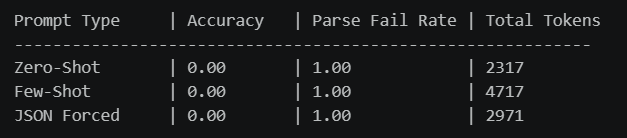

### อ่านตารางนี้อย่างไร

zero-shot, few-shot, json เสียคะแนนทั้งหมดไปกับรูปแบบ (Parse Failure 100%) โมเดลจริงมีความเข้าใจภาษาและวิเคราะห์ความรู้สึกได้ แต่ตอบกลับมาโดยมีข้อความอธิบายพ่วงมาด้วย (เช่น "จากการวิเคราะห์ สรุปได้ว่าเชิงบวก") หรือตอบเป็นภาษาอังกฤษ ทำให้ระบบตรวจประเมินที่คาดหวังคำตอบแบบเป๊ะ ๆ ตัดสินว่าผิดพลาดทั้งหมด
few-shot แลกมาด้วยการจ่ายโทเคนเพิ่มขึ้นเกือบเท่าตัว (236 โทเคน/เคส เทียบกับ 116 โทเคน/เคส) เพื่อส่งตัวอย่าง แต่ก็ยังไม่สามารถบังคับโมเดลให้ละทิ้งข้อความเกริ่นนำตามธรรมชาติของมันได้
json ใช้โทเคนคุ้มค่ากว่า few-shot (149 โทเคน/เคส) แต่ก็ยัง parse ไม่ผ่านเพราะโมเดลจริงมักจะครอบคำตอบด้วย Markdown Code Block (เช่น ```json ... ```) หรือตั้งชื่อ Key ไม่ตรงกับที่ระบบคาดหวัง

#### เคสที่ทุกพรอมป์ตยังพลาด (หากข้ามปัญหาการ Parse ไปได้)
(ลบ) "นึกว่าเป็นร้านอาหาร ที่ไหนได้หวานอย่างกับร้านขนม"

(ลบ) "อาหารอร่อยมาก แต่กินเสร็จแล้วท้องเสีย"

(ลบ) "เปิดเพลงดังรบกวน พูดด้วยก็ไม่ได้ยิน"

#### สาเหตุร่วมกันคือ รูปแบบการตอบหรือโครงสร้าง Prompt ไม่ได้ช่วยแก้ปัญหาที่ตัวโมเดลตีความภาษาและบริบทยาก ๆ ผิดพลาด โดยมีสาเหตุดังนี้:
การประชด (Sarcasm) "หวานอย่างกับร้านขนม" โมเดลให้น้ำหนักคำว่า หวาน/ขนม เป็นเชิงบวก โดยไม่เข้าใจบริบทความคาดหวังต่ออาหารคาว
ประโยคขัดแย้งที่มีผลลัพธ์รุนแรง (Mixed Sentiment) "อร่อย...แต่ท้องเสีย" โมเดลเห็นทั้งคำเชิงบวกและลบ จึงนำมาหักล้างกันเป็น "กลาง" หรือเอนเอียงไปทางคำชมแรก โดยไม่ได้ให้น้ำหนักว่าอาการป่วยคือประสบการณ์เชิงลบขั้นสุด
การบอกเล่าสถานการณ์เชิงลบแฝง (Implicit Negative) "เปิดเพลงดังรบกวน..." ประโยคนี้อธิบายสภาพแวดล้อมทางกายภาพโดยไม่มีคำด่าทอชัดเจน โมเดลจึงตีความเป็นการบอกเล่าข้อเท็จจริงและให้ค่าเป็น "กลาง"

#### ข้อสรุปที่ใช้ต่อได้: 
การแก้ด้วยการปรับพรอมป์ตเฉย ๆ ไม่เพียงพอ ต้องแก้ปัญหา 2 ระดับ คือ 1) ระดับโค้ดประเมิน: ต้องใช้ Regex ที่ยืดหยุ่นขึ้นเพื่อดึงเฉพาะ Keyword ออกมาจากประโยคยาว ๆ หรือลบ Markdown block ทิ้งก่อน Parse JSON 2) ระดับความแม่นยำ: ต้องเพิ่มเคสตัวอย่างแบบกำกวม (ประชด, ประโยคขัดแย้ง) เข้าไปใน few-shot โดยตรง หรือยอมรับว่าเป็นข้อจำกัดและใช้ฟิลด์ confidence ใน JSON เพื่อคัดกรองเคสที่โมเดลไม่มั่นใจส่งให้มนุษย์รีวิวต่อ

#### เรื่อง prompt injection: 
การทดสอบกับโมเดลจริงพบว่า เมื่อไม่มีการป้องกัน โมเดลจะละทิ้งคำสั่งหลักและทำตามคำสั่งแปลกปลอมที่แทรกมาทันที แต่เมื่อใช้พรอมป์ตแบบ DEFENDED ที่มีการแยกข้อมูลด้วยแท็ก (เช่น <doc>...) อย่างชัดเจน โมเดลสามารถแยกแยะได้ว่าส่วนใดคือคำสั่งและส่วนใดคือข้อมูล ทำให้การป้องกันได้ผลจริง